In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [173]:
df = pd.read_csv("../data/Unemployment in India.csv")

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [174]:
# Dataset ka basic overview

print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset information:")
df.info()

Shape of dataset: (768, 7)

Column names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

First 5 rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [175]:
# Missing values check

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [176]:
# Duplicate rows check

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 27


In [177]:
# Remove extra spaces from column names

df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [178]:
df = df.rename(columns={
    'Estimated Unemployment Rate (%)': 'Unemployment_Rate',
    'Estimated Employed': 'Employed',
    'Estimated Labour Participation Rate (%)': 'Labour_Participation'
})

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed', 'Labour_Participation', 'Area']


In [179]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print(df['Date'].head())

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[us]


In [180]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

df.head()

,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation,Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019.0,5.0,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019.0,6.0,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019.0,7.0,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019.0,8.0,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019.0,9.0,September


In [181]:
print("Average Unemployment Rate:",
      df['Unemployment_Rate'].mean())

print("Maximum Unemployment Rate:",
      df['Unemployment_Rate'].max())

print("Minimum Unemployment Rate:",
      df['Unemployment_Rate'].min())

Average Unemployment Rate: 11.787945945945946
Maximum Unemployment Rate: 76.74
Minimum Unemployment Rate: 0.0


,Unemployment_Rate,Labour_Participation
Unemployment_Rate,1.000000,0.002558
Labour_Participation,0.002558,1.000000


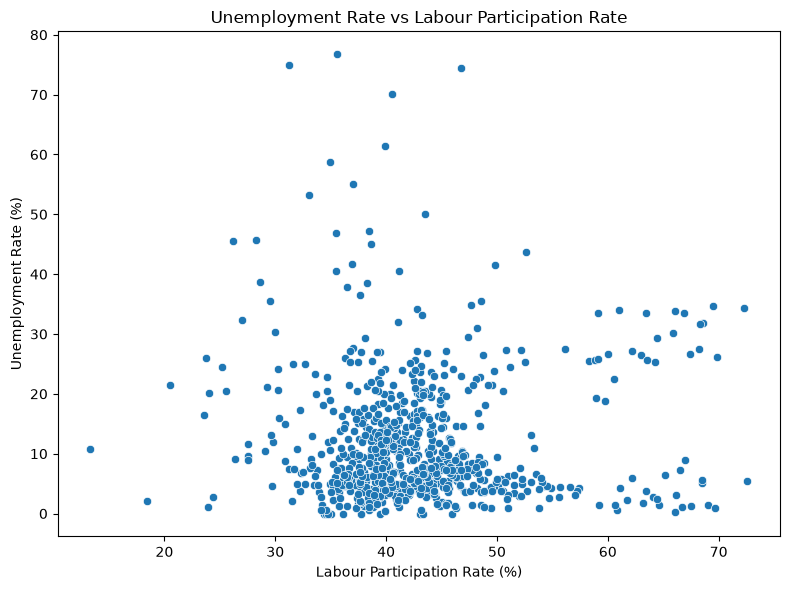

In [211]:
# Relationship Between Unemployment and Labour Participation

correlation = df[
    ['Unemployment_Rate', 'Labour_Participation']
].corr()

display(correlation)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Labour_Participation',
    y='Unemployment_Rate'
)

plt.title("Unemployment Rate vs Labour Participation Rate")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()

plt.savefig("../graphs/labour_participation.png", dpi=300, bbox_inches="tight")
plt.show()

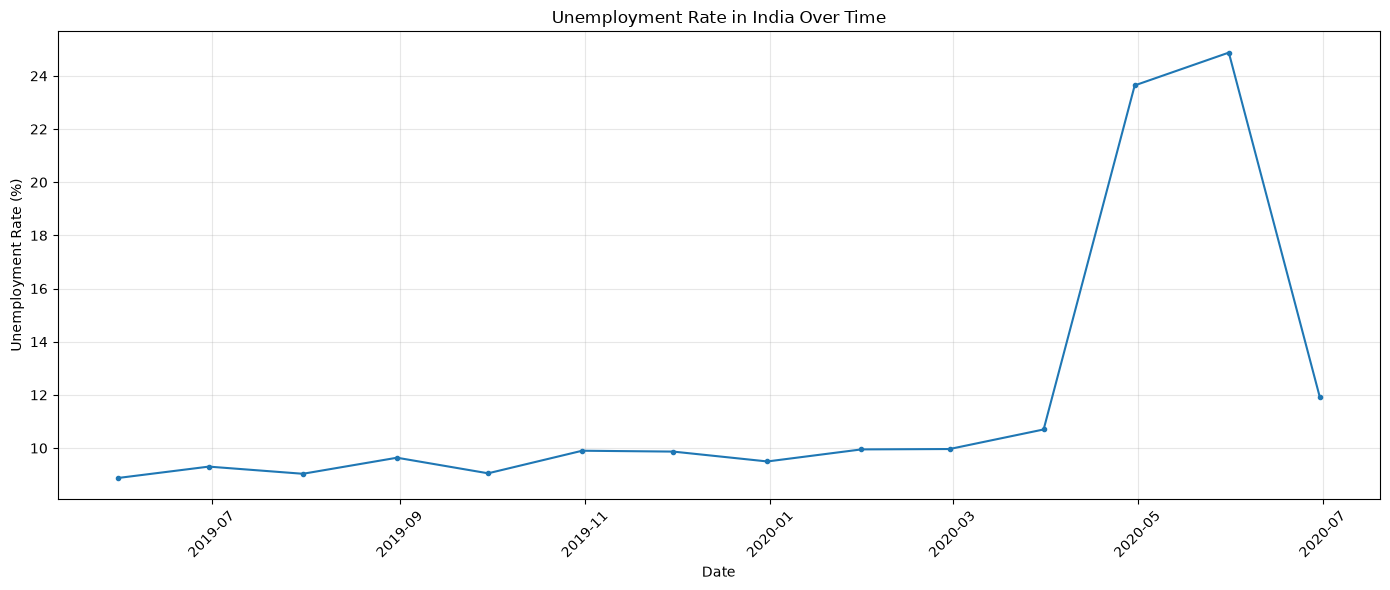

In [183]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_unemployment.index,
    daily_unemployment.values,
    marker='o',
    markersize=3
)

plt.title("Unemployment Rate in India Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("../graphs/unemployment_trend.png", dpi=300)
plt.show()

In [184]:
# Create COVID period classification

def classify_period(year):
    if year < 2020:
        return "Before COVID"
    else:
        return "COVID Period"

df['Period'] = df['Year'].apply(classify_period)

df[['Year', 'Period']].drop_duplicates()

,Year,Period
0,2019.0,Before COVID
8,2020.0,COVID Period
359,NaN,COVID Period


In [185]:
# Compare unemployment before and during COVID period

covid_analysis = (
    df.groupby('Period')['Unemployment_Rate']
    .mean()
)

print(covid_analysis)

Period
Before COVID     9.399047
COVID Period    15.101581
Name: Unemployment_Rate, dtype: float64


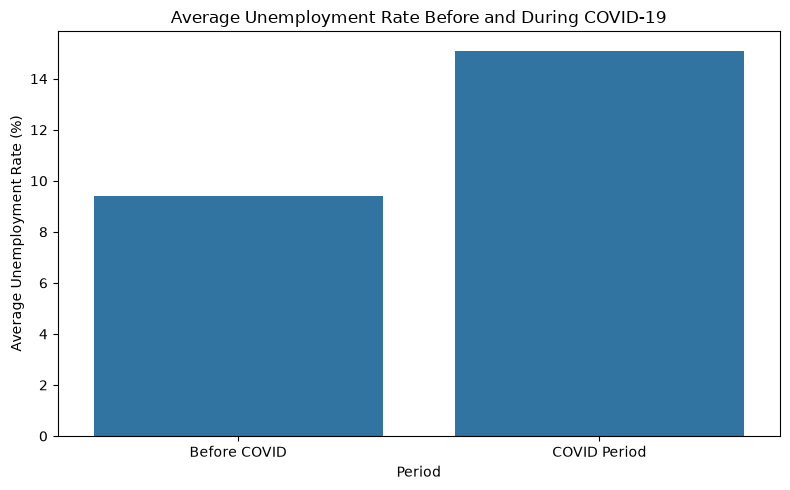

In [186]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=covid_analysis.index,
    y=covid_analysis.values
)

plt.title("Average Unemployment Rate Before and During COVID-19")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.savefig("../graphs/unemployment_trend.png")
plt.show()

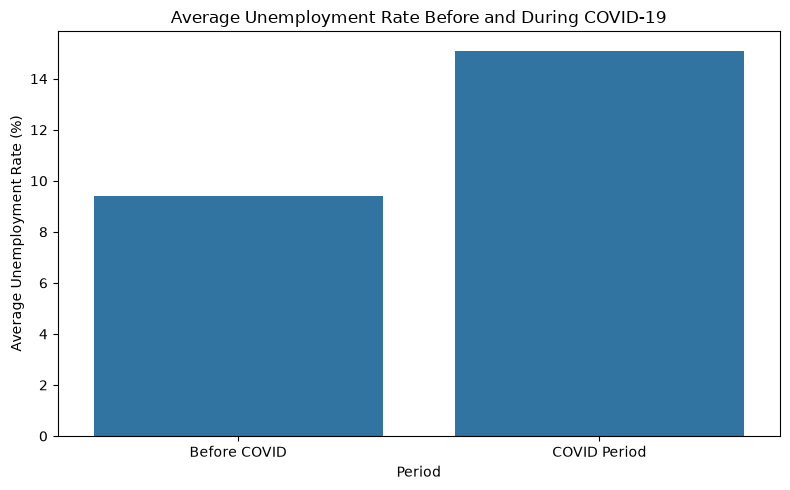

In [187]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=covid_analysis.index,
    y=covid_analysis.values
)

plt.title("Average Unemployment Rate Before and During COVID-19")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

In [188]:
print("Average unemployment rate before COVID:",
      covid_analysis["Before COVID"])

print("Average unemployment rate during COVID:",
      covid_analysis["COVID Period"])

increase = (
    covid_analysis["COVID Period"]
    - covid_analysis["Before COVID"]
)

print("Increase in percentage points:", increase)

Average unemployment rate before COVID: 9.399046511627906
Average unemployment rate during COVID: 15.10158064516129
Increase in percentage points: 5.7025341335333835


In [189]:
# State-wise average unemployment rate

state_unemployment = (
    df.groupby('Region')['Unemployment_Rate']
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 regions with highest average unemployment rate:")
print(state_unemployment.head(10))

Top 10 regions with highest average unemployment rate:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Unemployment_Rate, dtype: float64


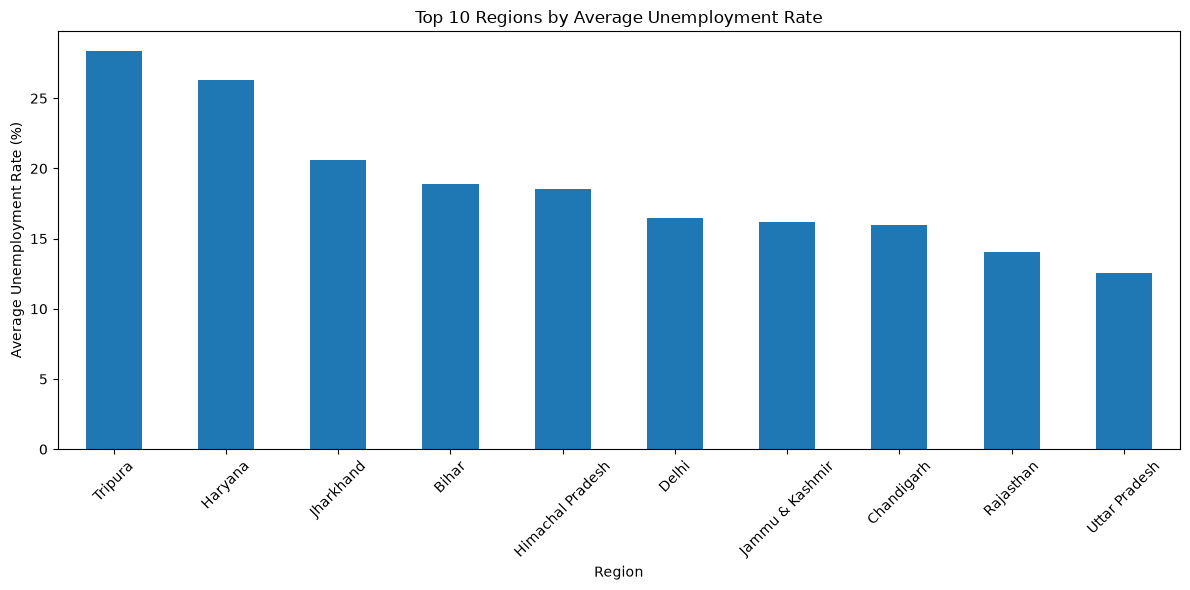

In [190]:
plt.figure(figsize=(12, 6))

state_unemployment.head(10).plot(kind='bar')

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [191]:
# COVID impact by region

before = df[df['Year'] < 2020]
during = df[df['Year'] == 2020]

before_state = (
    before.groupby('Region')['Unemployment_Rate']
    .mean()
)

during_state = (
    during.groupby('Region')['Unemployment_Rate']
    .mean()
)

state_covid = pd.concat(
    [before_state, during_state],
    axis=1
)

state_covid.columns = [
    'Before_COVID',
    'During_COVID'
]

state_covid['Change'] = (
    state_covid['During_COVID']
    - state_covid['Before_COVID']
)

state_covid = state_covid.sort_values(
    'Change',
    ascending=False
)

print("Top 10 regions with highest increase during COVID:")
display(state_covid.head(10))

Top 10 regions with highest increase during COVID:


,Before_COVID,During_COVID,Change
Region,,,
Puducherry,1.699375,23.840000,22.140625
Jharkhand,14.233750,29.053333,14.819583
Tamil Nadu,3.063750,17.578333,14.514583
Bihar,13.882500,25.632500,11.750000
Telangana,4.115625,12.567500,8.451875
Haryana,22.798750,30.929167,8.130417
Karnataka,3.238750,11.259167,8.020417
Kerala,7.131250,14.114167,6.982917
Delhi,13.750625,20.155000,6.404375


Top 10 regions with highest increase during COVID:


,Before_COVID,During_COVID,Change
Region,,,
Puducherry,1.699375,23.840000,22.140625
Jharkhand,14.233750,29.053333,14.819583
Tamil Nadu,3.063750,17.578333,14.514583
Bihar,13.882500,25.632500,11.750000
Telangana,4.115625,12.567500,8.451875
Haryana,22.798750,30.929167,8.130417
Karnataka,3.238750,11.259167,8.020417
Kerala,7.131250,14.114167,6.982917
Delhi,13.750625,20.155000,6.404375


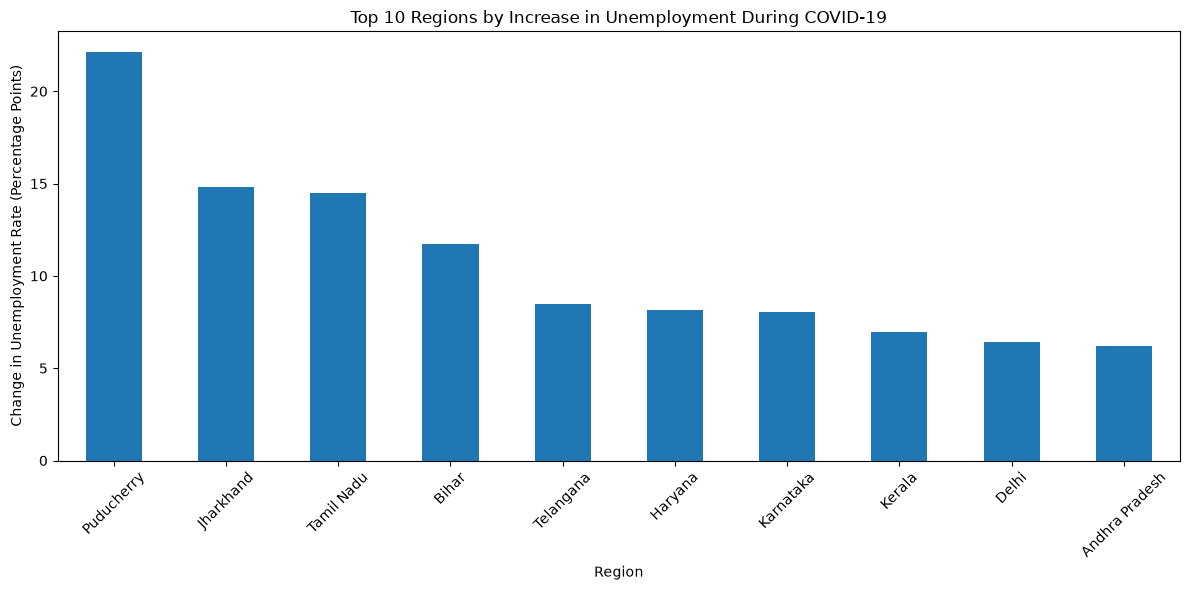

In [209]:
# COVID Impact by Region

before = df[df['Year'] < 2020]
during = df[df['Year'] == 2020]

before_state = (
    before.groupby('Region')['Unemployment_Rate']
    .mean()
)

during_state = (
    during.groupby('Region')['Unemployment_Rate']
    .mean()
)

state_covid = pd.concat(
    [before_state, during_state],
    axis=1
)

state_covid.columns = [
    'Before_COVID',
    'During_COVID'
]

state_covid['Change'] = (
    state_covid['During_COVID']
    - state_covid['Before_COVID']
)

state_covid = state_covid.sort_values(
    'Change',
    ascending=False
)

print("Top 10 regions with highest increase during COVID:")
display(state_covid.head(10))

plt.figure(figsize=(12, 6))

state_covid['Change'].head(10).plot(kind='bar')

plt.title("Top 10 Regions by Increase in Unemployment During COVID-19")
plt.xlabel("Region")
plt.ylabel("Change in Unemployment Rate (Percentage Points)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../graphs/covid_region_impact.png", dpi=300, bbox_inches="tight")
plt.show()

In [193]:
print("Top 10 regions most affected by COVID-19:")
display(state_covid.head(10))

Top 10 regions most affected by COVID-19:


,Before_COVID,During_COVID,Change
Region,,,
Puducherry,1.699375,23.840000,22.140625
Jharkhand,14.233750,29.053333,14.819583
Tamil Nadu,3.063750,17.578333,14.514583
Bihar,13.882500,25.632500,11.750000
Telangana,4.115625,12.567500,8.451875
Haryana,22.798750,30.929167,8.130417
Karnataka,3.238750,11.259167,8.020417
Kerala,7.131250,14.114167,6.982917
Delhi,13.750625,20.155000,6.404375


In [194]:
print("Top 10 regions most affected by COVID-19:")

display(state_covid.head(10))

Top 10 regions most affected by COVID-19:


,Before_COVID,During_COVID,Change
Region,,,
Puducherry,1.699375,23.840000,22.140625
Jharkhand,14.233750,29.053333,14.819583
Tamil Nadu,3.063750,17.578333,14.514583
Bihar,13.882500,25.632500,11.750000
Telangana,4.115625,12.567500,8.451875
Haryana,22.798750,30.929167,8.130417
Karnataka,3.238750,11.259167,8.020417
Kerala,7.131250,14.114167,6.982917
Delhi,13.750625,20.155000,6.404375


In [195]:
print("Top 10 regions most affected by COVID-19:")
display(state_covid.head(10))

Top 10 regions most affected by COVID-19:


,Before_COVID,During_COVID,Change
Region,,,
Puducherry,1.699375,23.840000,22.140625
Jharkhand,14.233750,29.053333,14.819583
Tamil Nadu,3.063750,17.578333,14.514583
Bihar,13.882500,25.632500,11.750000
Telangana,4.115625,12.567500,8.451875
Haryana,22.798750,30.929167,8.130417
Karnataka,3.238750,11.259167,8.020417
Kerala,7.131250,14.114167,6.982917
Delhi,13.750625,20.155000,6.404375


In [196]:
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

monthly_unemployment = (
    df.groupby('Month_Name')['Unemployment_Rate']
    .mean()
    .reindex(month_order)
)

display(monthly_unemployment)

Month_Name
January       9.950755
February      9.964717
March        10.700577
April        23.641569
May          16.646190
June         10.553462
July          9.033889
August        9.637925
September     9.051731
October       9.900909
November      9.868364
December      9.497358
Name: Unemployment_Rate, dtype: float64

Month_Name
January       9.950755
February      9.964717
March        10.700577
April        23.641569
May          16.646190
June         10.553462
July          9.033889
August        9.637925
September     9.051731
October       9.900909
November      9.868364
December      9.497358
Name: Unemployment_Rate, dtype: float64

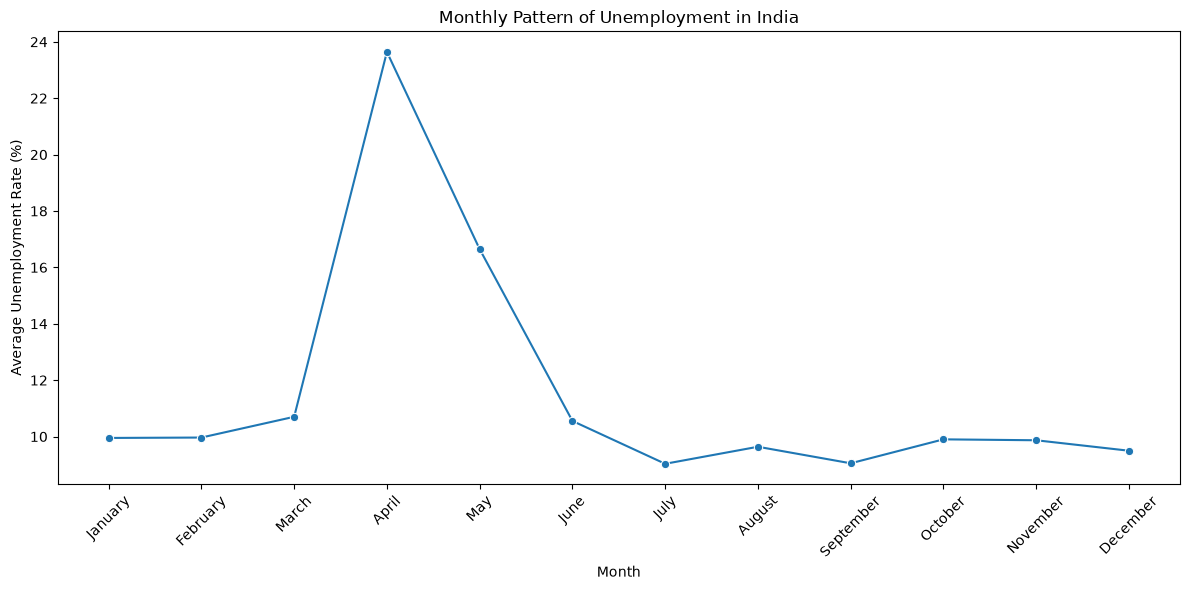

In [210]:
# Monthly Unemployment Analysis

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_unemployment = (
    df.groupby('Month_Name')['Unemployment_Rate']
    .mean()
    .reindex(month_order)
)

display(monthly_unemployment)

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_unemployment.index,
    y=monthly_unemployment.values,
    marker='o'
)

plt.title("Monthly Pattern of Unemployment in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../graphs/monthly_unemployment.png", dpi=300, bbox_inches="tight")
plt.show()

In [198]:
# Relationship between unemployment and labour participation

correlation = df[
    ['Unemployment_Rate', 'Labour_Participation']
].corr()

display(correlation)

,Unemployment_Rate,Labour_Participation
Unemployment_Rate,1.000000,0.002558
Labour_Participation,0.002558,1.000000


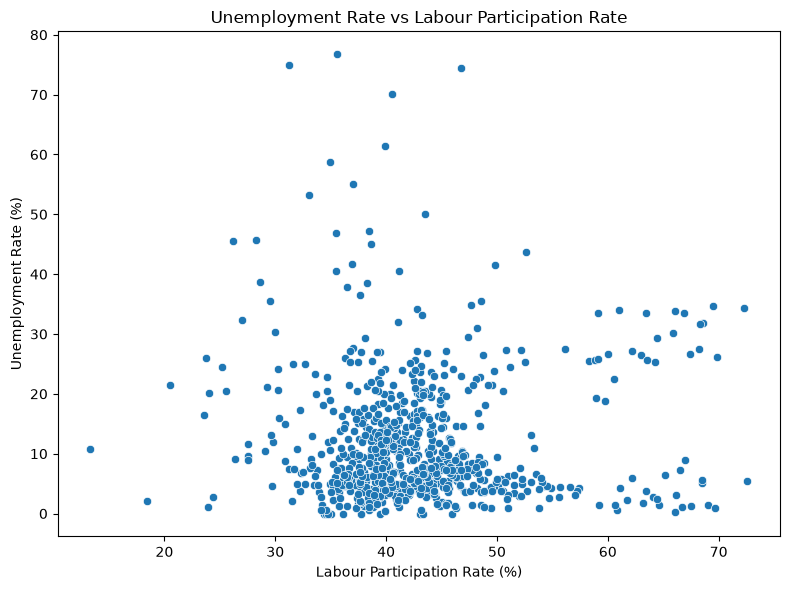

In [199]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Labour_Participation',
    y='Unemployment_Rate'
)

plt.title("Unemployment Rate vs Labour Participation Rate")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")

plt.tight_layout()
plt.show()

In [200]:
# Region-wise unemployment rate by year

heatmap_data = df.pivot_table(
    index='Region',
    columns='Year',
    values='Unemployment_Rate',
    aggfunc='mean'
)

display(heatmap_data)

Year,2019.0,2020.0
Region,,
Andhra Pradesh,4.826875,11.010833
Assam,6.420667,6.438182
Bihar,13.882500,25.632500
Chandigarh,15.822500,16.330000
Chhattisgarh,7.346875,11.765000
Delhi,13.750625,20.155000
Goa,9.346250,9.130000
Gujarat,4.979375,8.910000
Haryana,22.798750,30.929167


Top 10 regions with highest average unemployment rate:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Unemployment_Rate, dtype: float64


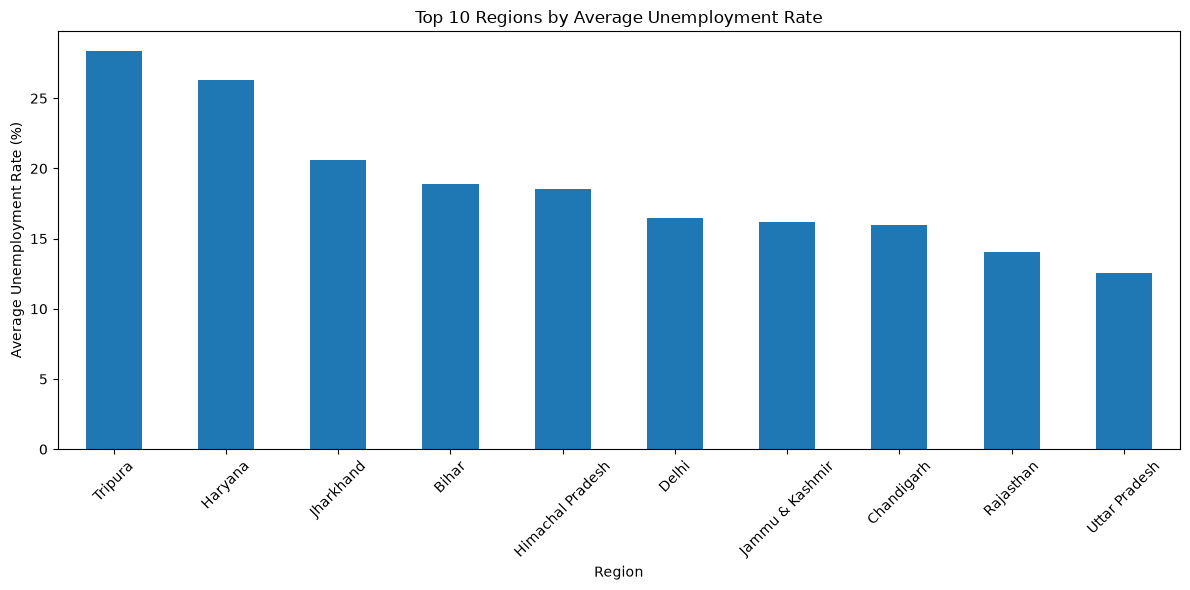

In [208]:
# Region-wise Average Unemployment Rate

state_unemployment = (
    df.groupby('Region')['Unemployment_Rate']
    .mean()
    .sort_values(ascending=False)
)

print("Top 10 regions with highest average unemployment rate:")
print(state_unemployment.head(10))

plt.figure(figsize=(12, 6))

state_unemployment.head(10).plot(kind='bar')

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../graphs/regional_unemployment.png", dpi=300, bbox_inches="tight")
plt.show()

In [202]:
heatmap_data = df.pivot_table(
    index='Region',
    columns='Year',
    values='Unemployment_Rate',
    aggfunc='mean'
)

display(heatmap_data)

Year,2019.0,2020.0
Region,,
Andhra Pradesh,4.826875,11.010833
Assam,6.420667,6.438182
Bihar,13.882500,25.632500
Chandigarh,15.822500,16.330000
Chhattisgarh,7.346875,11.765000
Delhi,13.750625,20.155000
Goa,9.346250,9.130000
Gujarat,4.979375,8.910000
Haryana,22.798750,30.929167


Year,2019.0,2020.0
Region,,
Andhra Pradesh,4.826875,11.010833
Assam,6.420667,6.438182
Bihar,13.882500,25.632500
Chandigarh,15.822500,16.330000
Chhattisgarh,7.346875,11.765000
Delhi,13.750625,20.155000
Goa,9.346250,9.130000
Gujarat,4.979375,8.910000
Haryana,22.798750,30.929167


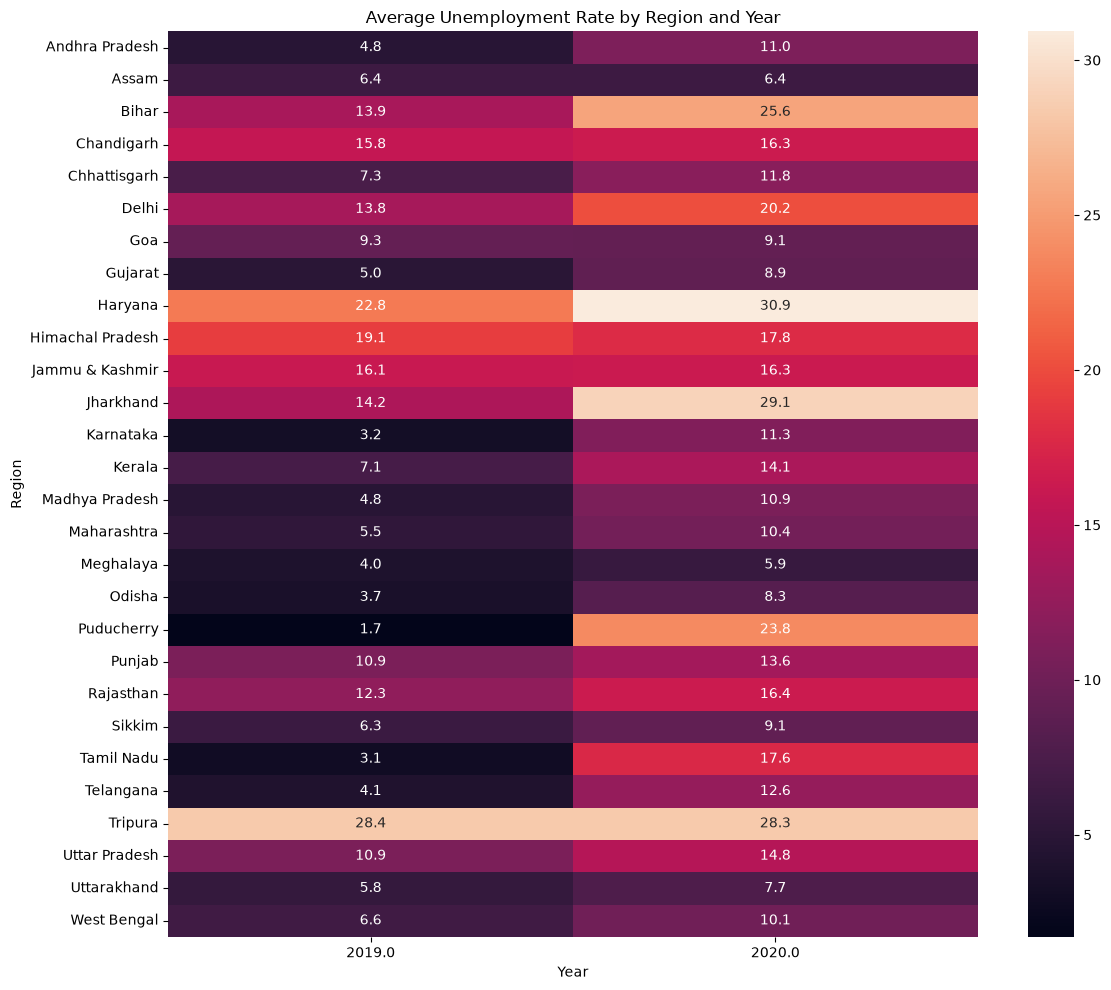

In [212]:
# Regional Heatmap

heatmap_data = df.pivot_table(
    index='Region',
    columns='Year',
    values='Unemployment_Rate',
    aggfunc='mean'
)

display(heatmap_data)

plt.figure(figsize=(12, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f'
)

plt.title("Average Unemployment Rate by Region and Year")
plt.xlabel("Year")
plt.ylabel("Region")
plt.tight_layout()

plt.savefig("../graphs/regional_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [204]:
import sys
print(sys.executable)

c:\Users\vansh\OneDrive\Desktop\Unemployment Analysis\venv\Scripts\python.exe


# Key Findings

1. The average unemployment rate in the dataset was approximately 11.79%.

2. The unemployment rate showed a sharp increase during the early COVID-19 period, particularly around April 2020.

3. April recorded the highest monthly average unemployment rate at approximately 23.64%.

4. Puducherry experienced the largest increase in unemployment during the COVID-19 period, with an increase of approximately 22.14 percentage points compared with its pre-COVID average.

5. Jharkhand and Tamil Nadu also experienced substantial increases in unemployment during the COVID-19 period.

6. Unemployment rates varied considerably across different regions of India.

7. The correlation between unemployment rate and labour participation rate was approximately 0.003, indicating almost no linear relationship in this dataset.

8. The regional heatmap shows that many regions experienced higher unemployment in 2020 compared with 2019.

# Policy Recommendations

Based on the unemployment analysis, the following policy recommendations can be considered:

### 1. Create More Employment Opportunities

The government can encourage industries and businesses to create more jobs, especially in regions with consistently high unemployment rates.

### 2. Support Small and Medium Businesses

Small and medium-sized businesses can be supported through easier access to loans, financial assistance, and business incentives. This can help businesses create and maintain employment.

### 3. Improve Skill Development

Skill development and vocational training programs can help unemployed people develop skills that match current market requirements.

### 4. Provide Targeted Regional Support

Regions experiencing higher unemployment should receive targeted employment programs and investment rather than relying only on nationwide policies.

### 5. Strengthen Support During Economic Crises

The sharp increase in unemployment during the COVID-19 period shows the importance of emergency employment and income-support programs during major economic disruptions.

### 6. Encourage Digital and Remote Employment

Expanding digital skills, internet access, and remote-work opportunities can provide additional employment opportunities, especially during periods when traditional workplaces are disrupted.

### 7. Improve Employment Data Monitoring

Regular monitoring of unemployment and labour-market indicators can help policymakers identify sudden changes and respond more quickly.

# Conclusion

This project analyzed unemployment trends in India using Python, Pandas, Matplotlib, and Seaborn.

The analysis showed that unemployment varied considerably across different regions and months. A major increase in unemployment was observed during the early COVID-19 period, with April 2020 showing the highest monthly average unemployment rate in the dataset.

The regional analysis showed that the impact of COVID-19 was not uniform across India. Some regions experienced much larger increases in unemployment than others. The analysis also found almost no linear correlation between unemployment rate and labour participation rate in this dataset.

Overall, the project demonstrates how data analysis and visualization can be used to understand unemployment patterns, identify regions and periods of higher unemployment, and provide useful insights for economic and social policy planning.

In [205]:
import os
print(os.getcwd())

c:\Users\vansh\OneDrive\Desktop\Unemployment Analysis\notebook


In [206]:
import os

os.makedirs("../graphs", exist_ok=True)

plt.savefig("../graphs/test_graph.png", dpi=300)

print("Graph saved successfully!")

Graph saved successfully!


<Figure size 640x480 with 0 Axes>

In [207]:
import os
print(os.path.abspath("../graphs"))

c:\Users\vansh\OneDrive\Desktop\Unemployment Analysis\graphs
